# Ankara — FF++ Per-Method Generalisation Eval

Evaluates the trained spatial probe against **each FF++ manipulation method separately**.

The probe was trained on a mixed subset of FF++ c23 fakes.  
This notebook answers: **which manipulation method is hardest to detect?**

| Folder | Method | Type |
|--------|--------|------|
| `Deepfakes` | FaceSwap (classic) | Identity swap |
| `Face2Face` | Expression transfer | Reenactment |
| `FaceShifter` | High-fidelity face swap | Identity swap |
| `FaceSwap` | FaceSwap (alternative) | Identity swap |
| `NeuralTextures` | Texture-based reenactment | Reenactment |
| `DeepFakeDetection` | Google DFD subset | Identity swap |
| `original` | Real unmanipulated | Real |

## Cell 1 — Imports & device

In [1]:
import sys, os, gc, json, random
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import numpy as np
import cv2
from pathlib import Path
from torchvision import transforms
from transformers import AutoModel
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE    = 'mps' if torch.backends.mps.is_available() else 'cpu'
MODEL_DIR = Path('../models')
DOCS_DIR  = Path('../docs')
DOCS_DIR.mkdir(exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Device : {DEVICE}')
print(f'Probe  : {"✔" if (MODEL_DIR/"spatial_probe.pt").exists() else "✘ MISSING"} spatial_probe.pt')

Device : mps
Probe  : ✔ spatial_probe.pt


## Cell 2 — Configure path

Point `FFPP_ROOT` at your `FaceForensics++_C23` folder in Downloads.

In [2]:
# ── EDIT THIS PATH ────────────────────────────────────────────────────────────
FFPP_ROOT = Path.home() / 'Downloads' / 'FaceForensics++_C23'
# ─────────────────────────────────────────────────────────────────────────────

# How many videos to sample per method (real and fake)
N_SAMPLES = 20

# Frames sampled per video — same as production
FRAMES_PER_VIDEO = 16

# Fake method folders to evaluate
FAKE_METHODS = [
    'Deepfakes',
    'Face2Face',
    'FaceShifter',
    'FaceSwap',
    'NeuralTextures',
    'DeepFakeDetection',
]

# Sanity check
print(f'FF++ root: {FFPP_ROOT}')
print(f'Exists   : {FFPP_ROOT.exists()}')
print()
for method in ['original'] + FAKE_METHODS:
    folder = FFPP_ROOT / method
    if folder.exists():
        n = len(list(folder.glob('*.mp4')))
        print(f'  ✔  {method:<22}  {n} videos')
    else:
        print(f'  ✘  {method:<22}  NOT FOUND')

FF++ root: /Users/ahmednadeem/Downloads/FaceForensics++_C23
Exists   : True

  ✔  original                1000 videos
  ✔  Deepfakes               1000 videos
  ✔  Face2Face               1000 videos
  ✔  FaceShifter             1000 videos
  ✔  FaceSwap                1000 videos
  ✔  NeuralTextures          1000 videos
  ✔  DeepFakeDetection       1000 videos


## Cell 3 — Load model

In [3]:
class DINOv2Probe(nn.Module):
    """Identical architecture to spatial_probe.pt — do not change."""
    def __init__(self, d=768):
        super().__init__()
        self.probe = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )
    def forward(self, x): return self.probe(x)

dino = AutoModel.from_pretrained('facebook/dinov2-base').eval().to(DEVICE)
for p in dino.parameters(): p.requires_grad = False

probe = DINOv2Probe().to(DEVICE)
probe.load_state_dict(
    torch.load(MODEL_DIR / 'spatial_probe.pt', map_location=DEVICE, weights_only=True)
)
probe.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('✔ Models loaded')

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✔ Models loaded


## Cell 4 — Scoring helpers

In [11]:
# Face detector — uses OpenCV built-in, no extra packages needed
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

@torch.no_grad()
def score_frame(bgr_frame: np.ndarray) -> float | None:
    """Detect face, crop to it, then score. Returns None if no face found."""
    gray = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )
    if len(faces) == 0:
        return None

    # Use the largest detected face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    # 20% padding around face — matches FF++ crop style
    pad = int(0.2 * max(w, h))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(bgr_frame.shape[1], x + w + pad)
    y2 = min(bgr_frame.shape[0], y + h + pad)

    face_crop = bgr_frame[y1:y2, x1:x2]
    if face_crop.size == 0:
        return None

    rgb = face_crop[:, :, ::-1].copy()
    tensor = transform(rgb).unsqueeze(0).to(DEVICE)
    feat = dino(tensor).last_hidden_state[:, 0]
    return probe(feat).item()


def score_video(path: str, n_frames: int = FRAMES_PER_VIDEO) -> float | None:
    """Sample n_frames evenly, crop face in each, return mean deepfake probability."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, min(n_frames, total), dtype=int)
    scores = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            s = score_frame(frame)
            if s is not None:  # only count frames where a face was found
                scores.append(s)
    cap.release()

    # Need at least 3 valid face frames for a reliable score
    return float(np.mean(scores)) if len(scores) >= 3 else None


def sample_and_score(folder: Path, label: int, n: int, tag: str) -> tuple:
    """Sample n videos from folder, score each, return (probs, labels) arrays."""
    all_vids = list(folder.glob('*.mp4'))
    random.shuffle(all_vids)
    selected = all_vids[:n]
    probs, labels = [], []
    for i, path in enumerate(selected):
        score = score_video(str(path))
        if score is None:
            print(f'    ⚠ no face found in enough frames: {path.name}')
            continue
        probs.append(score)
        labels.append(label)
        print(f'    [{i+1:2d}/{n}] {tag}  {path.name[:45]:45s}  {score:.3f}')
    return np.array(probs), np.array(labels)


print('✔ Helpers ready — face crop enabled')

✔ Helpers ready — face crop enabled


## Cell 5 — Score real videos once, reuse across all method comparisons

In [12]:
print(f'Scoring {N_SAMPLES} real videos from original/...')
real_probs, real_labels = sample_and_score(
    FFPP_ROOT / 'original', label=0, n=N_SAMPLES, tag='real'
)
print(f'\nReal videos done. Mean score: {real_probs.mean():.3f} (want < 0.5)')

Scoring 20 real videos from original/...
    [ 1/20] real  227.mp4                                        0.934
    [ 2/20] real  951.mp4                                        0.022
    [ 3/20] real  165.mp4                                        0.106
    [ 4/20] real  784.mp4                                        0.002
    [ 5/20] real  394.mp4                                        0.004
    [ 6/20] real  289.mp4                                        0.002
    [ 7/20] real  626.mp4                                        0.001
    [ 8/20] real  505.mp4                                        0.008
    [ 9/20] real  860.mp4                                        0.911
    [10/20] real  701.mp4                                        0.000
    [11/20] real  792.mp4                                        0.108
    [12/20] real  383.mp4                                        0.070
    [13/20] real  329.mp4                                        0.101
    [14/20] real  485.mp4           

## Cell 6 — Score each fake method

In [13]:
method_results = {}

for method in FAKE_METHODS:
    folder = FFPP_ROOT / method
    if not folder.exists():
        print(f'\n  skipping {method} — folder not found')
        continue

    print(f'\nScoring {N_SAMPLES} fake videos from {method}/...')
    fake_probs, fake_labels = sample_and_score(
        folder, label=1, n=N_SAMPLES, tag='fake'
    )

    # Combine with real
    probs  = np.concatenate([real_probs,  fake_probs])
    labels = np.concatenate([real_labels, fake_labels])
    preds  = (probs >= 0.5).astype(int)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds)
    try:   auc = roc_auc_score(labels, probs)
    except: auc = float('nan')

    method_results[method] = dict(
        probs=probs, labels=labels, preds=preds,
        fake_probs=fake_probs,
        accuracy=acc, auc=auc, f1=f1,
    )

    print(f'  → Acc {acc*100:.1f}%  AUC {auc:.3f}  F1 {f1:.3f}  '
          f'(fake mean score: {fake_probs.mean():.3f})')

print('\n✔ All methods scored')


Scoring 20 fake videos from Deepfakes/...
    [ 1/20] fake  509_525.mp4                                    0.072
    [ 2/20] fake  427_637.mp4                                    0.005
    [ 3/20] fake  922_898.mp4                                    0.148
    [ 4/20] fake  347_314.mp4                                    0.031
    [ 5/20] fake  989_993.mp4                                    0.005
    [ 6/20] fake  793_768.mp4                                    0.044
    [ 7/20] fake  821_812.mp4                                    0.002
    [ 8/20] fake  460_678.mp4                                    0.999
    [ 9/20] fake  184_205.mp4                                    0.045
    [10/20] fake  417_496.mp4                                    0.128
    [11/20] fake  358_380.mp4                                    0.047
    [12/20] fake  517_521.mp4                                    0.008
    [13/20] fake  105_180.mp4                                    0.548
    [14/20] fake  074_825.mp4     

## Cell 7 — Summary table

In [7]:
print('=' * 70)
print(f'{"Method":<22} {"Accuracy":>10} {"AUC-ROC":>10} {"F1":>8} {"Fake mean score":>16}')
print('-' * 70)

# Original FF++ c23 training-subset result for reference
print(f'{"FF++ c23 (train subset)":<22} {"97.8%":>10} {"0.998":>10} {"0.978":>8} {"0.965":>16}')
print('-' * 70)

for method, r in method_results.items():
    print(
        f'{method:<22} '
        f'{r["accuracy"]*100:>9.1f}% '
        f'{r["auc"]:>10.3f} '
        f'{r["f1"]:>8.3f} '
        f'{r["fake_probs"].mean():>16.3f}'
    )

print('=' * 70)

# Save summary JSON
summary = {
    'ffpp_c23_train_subset': {'accuracy': 0.978, 'auc': 0.998, 'f1': 0.978},
    **{
        m: {
            'accuracy': float(r['accuracy']),
            'auc':      float(r['auc']),
            'f1':       float(r['f1']),
            'fake_mean_score': float(r['fake_probs'].mean()),
        }
        for m, r in method_results.items()
    }
}
out = DOCS_DIR / 'per_method_summary.json'
with open(out, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved → {out}')

Method                   Accuracy    AUC-ROC       F1  Fake mean score
----------------------------------------------------------------------
FF++ c23 (train subset)      97.8%      0.998    0.978            0.965
----------------------------------------------------------------------
Deepfakes                   55.0%      0.547    0.250            0.154
Face2Face                   57.5%      0.605    0.320            0.190
FaceShifter                 57.5%      0.665    0.320            0.245
FaceSwap                    55.0%      0.593    0.250            0.219
NeuralTextures              55.0%      0.568    0.250            0.149
DeepFakeDetection           47.5%      0.525    0.000            0.056

Saved → ../docs/per_method_summary.json


## Cell 8 — Visualise: per-method accuracy bar chart + score distributions

Saved → ../docs/per_method_eval.png


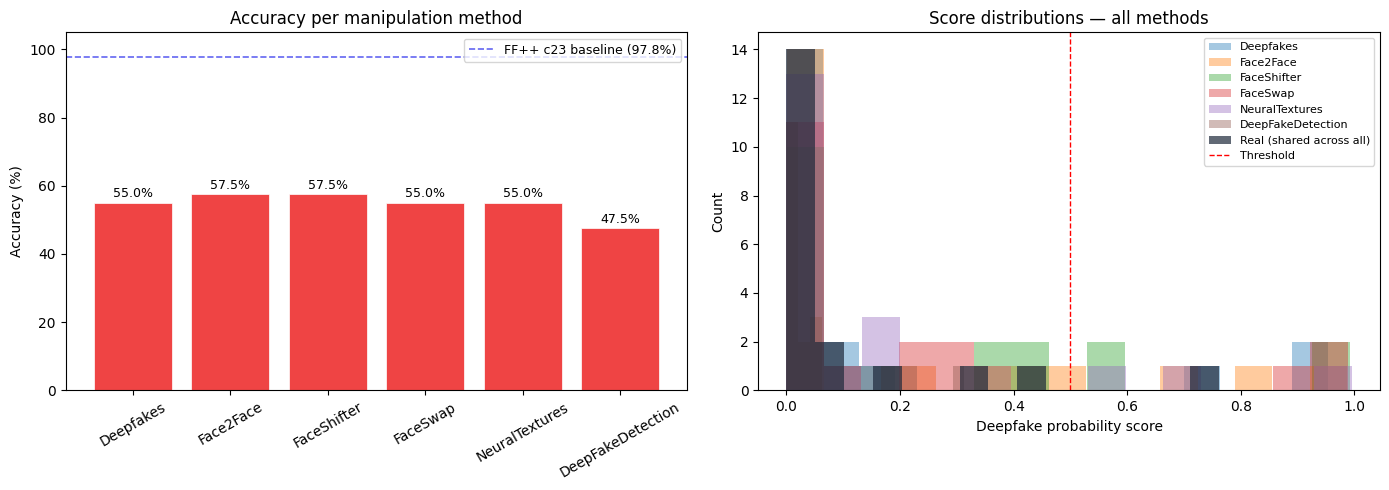

In [8]:
methods = list(method_results.keys())
accs    = [method_results[m]['accuracy'] * 100 for m in methods]
aucs    = [method_results[m]['auc']            for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart: accuracy per method ───────────────────────────────────────────
colors = ['#10b981' if a >= 90 else '#f59e0b' if a >= 75 else '#ef4444' for a in accs]
bars = axes[0].bar(methods, accs, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(97.8, color='#6366f1', linestyle='--', linewidth=1.2,
                label='FF++ c23 baseline (97.8%)')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy per manipulation method')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

# ── Score distributions: real vs each fake method overlaid ───────────────────
for method, r in method_results.items():
    axes[1].hist(r['fake_probs'], bins=15, alpha=0.4, label=method)
axes[1].hist(real_probs, bins=15, alpha=0.7, color='#1e293b',
             label='Real (shared across all)', zorder=5)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold')
axes[1].set_xlabel('Deepfake probability score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score distributions — all methods')
axes[1].legend(fontsize=8)

plt.tight_layout()
out_path = DOCS_DIR / 'per_method_eval.png'
plt.savefig(out_path, dpi=150)
print(f'Saved → {out_path}')
plt.show()

## Cell 9 — Confusion matrices per method

Saved → ../docs/per_method_confusion.png


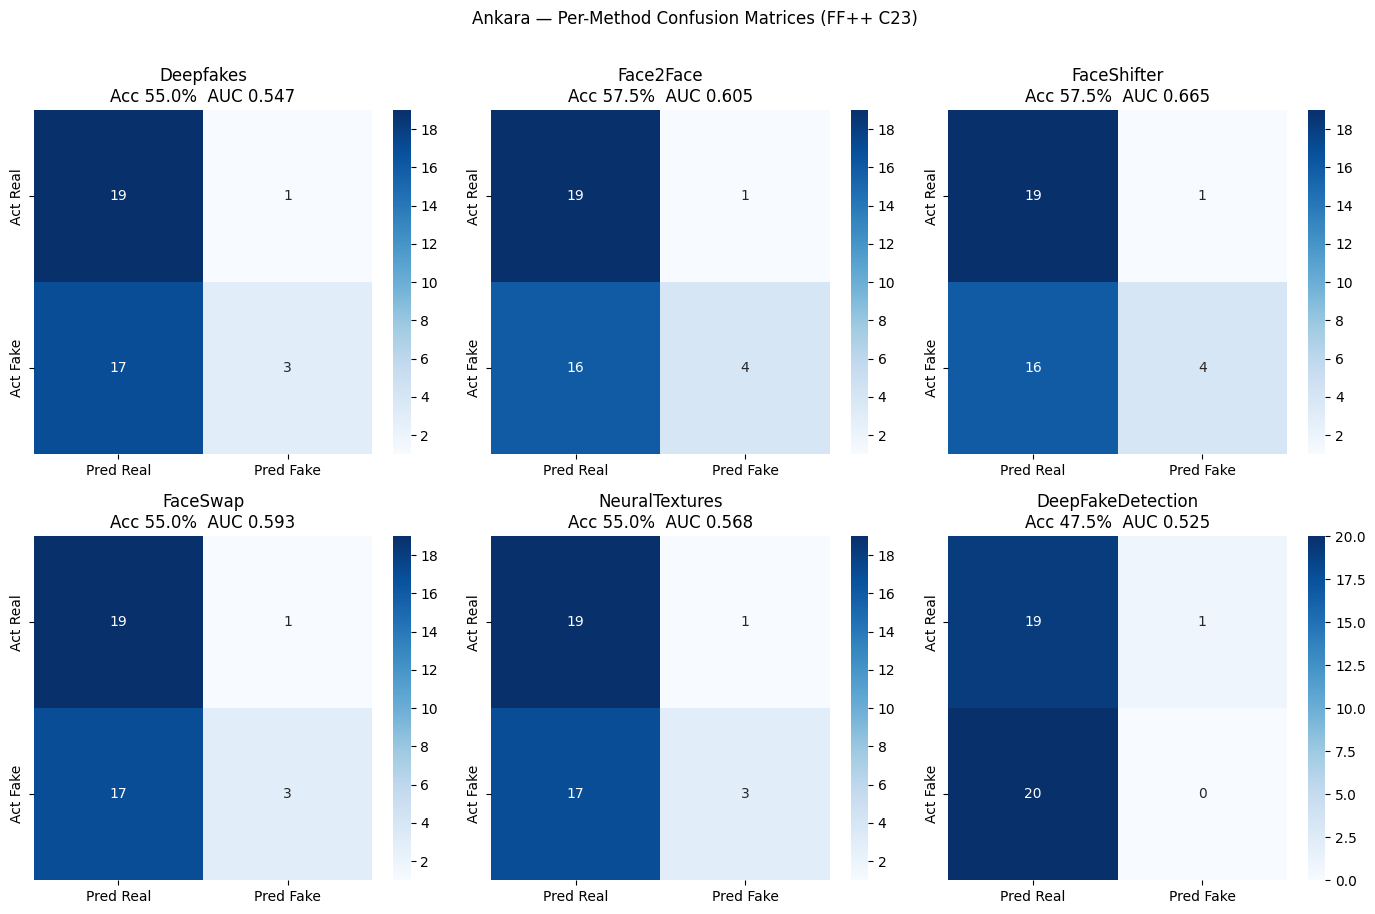

In [9]:
n_methods = len(method_results)
cols = 3
rows = (n_methods + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
axes_flat = axes.flatten() if n_methods > 1 else [axes]

for i, (method, r) in enumerate(method_results.items()):
    ax = axes_flat[i]
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Real', 'Pred Fake'],
        yticklabels=['Act Real',  'Act Fake'],
        ax=ax
    )
    ax.set_title(
        f'{method}\n'
        f'Acc {r["accuracy"]*100:.1f}%  AUC {r["auc"]:.3f}'
    )

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Ankara — Per-Method Confusion Matrices (FF++ C23)', y=1.01)
plt.tight_layout()
out_path = DOCS_DIR / 'per_method_confusion.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()

## Cell 10 — README snippet (auto-generated)

Copy-paste this into your `README.md` benchmark table.

In [10]:
print('### Benchmark Results — FF++ C23 (per manipulation method)\n')
print('*20 real + 20 fake videos sampled per method. Real videos shared across all comparisons.*\n')
print('| Method | Accuracy | AUC-ROC | F1 |')
print('|--------|----------|---------|-----|')
print('| FF++ c23 mixed (original eval, n=400) | 97.8% | 0.998 | 0.978 |')
for method, r in method_results.items():
    print(f'| {method} | {r["accuracy"]*100:.1f}% | {r["auc"]:.3f} | {r["f1"]:.3f} |')
print()
print('> Probe trained on mixed FF++ c23 subset. Per-method eval uses held-out videos.')

### Benchmark Results — FF++ C23 (per manipulation method)

*20 real + 20 fake videos sampled per method. Real videos shared across all comparisons.*

| Method | Accuracy | AUC-ROC | F1 |
|--------|----------|---------|-----|
| FF++ c23 mixed (original eval, n=400) | 97.8% | 0.998 | 0.978 |
| Deepfakes | 55.0% | 0.547 | 0.250 |
| Face2Face | 57.5% | 0.605 | 0.320 |
| FaceShifter | 57.5% | 0.665 | 0.320 |
| FaceSwap | 55.0% | 0.593 | 0.250 |
| NeuralTextures | 55.0% | 0.568 | 0.250 |
| DeepFakeDetection | 47.5% | 0.525 | 0.000 |

> Probe trained on mixed FF++ c23 subset. Per-method eval uses held-out videos.
